# 01 - Pareto RMSE vs Kendall Tau

Thin runner notebook for the rebuilt Pareto-style scatter figure.

This notebook uses `nb_utils.py` for all loading, styling, and export logic.

In [2]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "mrmr").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate project root containing mrmr/")


PROJECT_ROOT = find_project_root(Path.cwd())
NOTEBOOK_DIR = PROJECT_ROOT / "mrmr" / "viz" / "notebooks"
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import importlib
import nb_utils as _nb_utils

_nb_utils = importlib.reload(_nb_utils)

BINARY_DATASETS_DEFAULT = _nb_utils.BINARY_DATASETS_DEFAULT
CONTINUOUS_DATASETS_DEFAULT = _nb_utils.CONTINUOUS_DATASETS_DEFAULT
PASSK_BENCHMARKS_DEFAULT = _nb_utils.PASSK_BENCHMARKS_DEFAULT
build_mrmr_methods = _nb_utils.build_mrmr_methods
run_notebook_01 = _nb_utils.run_notebook_01


def mrmr_with_fallback(methods: list[str]) -> list[tuple[str, str]]:
    out: list[tuple[str, str]] = []
    for method in methods:
        out.append((method, method.replace("5_", "_")))
    return out


# -------------------------------
# Data + settings controls
# -------------------------------
BINARY_SETTING = ("binned_interpolation", "5%", "30")
CONTINUOUS_SETTING = ("stratified", "5%", "16")
PASSK_SETTING = ("stratified", "5%", "15")

BINARY_DATASETS = [
    "ifeval",
    "openllm_math",
    "mmlu_pro",
    "arc_challenge",
    "bbh",
    "gpqa",
    "musr",
    "commonsense",
    "gsm",
    "legalbench",
    "math",
    "med_qa",
    "mmlu",
]

CONTINUOUS_DATASETS = [
    "biolaysumm_rougel",
    "biolaysumm_bertscore",
    "biolaysumm_fkgl",
    "govreport_rougel",
    "govreport_bertscore",
    "truthfulqa_judge",
    # "nemotron_pii",
]

PASSK_BENCHMARKS = [
    # ,
    "LBPP_Python",
    "HumanEvalPack_PythonPlus",
    "MBPPPlus_mbpp_plus",
    "MBPP_mbpp",
]

BINARY_DATASETS = BINARY_DATASETS or BINARY_DATASETS_DEFAULT
CONTINUOUS_DATASETS = CONTINUOUS_DATASETS or CONTINUOUS_DATASETS_DEFAULT
PASSK_BENCHMARKS = PASSK_BENCHMARKS or PASSK_BENCHMARKS_DEFAULT

# -------------------------------
# Method controls
# -------------------------------
BINARY_BASE_METHODS: list[str | tuple[str, ...]] = [
    "random_sampling",
    "lasso",
    "random_sampling_and_learn",
    "krandom_sampling_and_learn",
    "random_search_and_learn",
    "krandom_search_and_learn",
    # "small_search_and_learn",
    # "ksmall_search_and_learn",
    "kanchor_points_predictor",
    "anchor_points_weighted",
    "anchor_points_weighted+",
    "kanchor_points_weighted+",
    # "pirt1",
    "gpirt1",
    # "pirt1+",
    "gpirt1+",
    # "kpirt1+",
    "kgpirt1+",
    "metabench",
]

BINARY_MRMR_METHODS = mrmr_with_fallback(
    build_mrmr_methods(
        degrees=[1, 2],
        mi_ks=[5],
        objectives=["MIQ"],
        targets=["y"],
    )
)

METHODS_BINARY = [
    *BINARY_BASE_METHODS,
    *BINARY_MRMR_METHODS,
]

CONT_BASE_METHODS: list[str | tuple[str, ...]] = [
    "random_sampling",
    "lasso",
    "random_sampling_and_learn",
    "krandom_sampling_and_learn",
    "random_search_and_learn",
    "krandom_search_and_learn",
    # "small_search_and_learn",
    # "ksmall_search_and_learn",
    "anchor_points_weighted",
    "anchor_points_weighted+",
    "kanchor_points_weighted+",
    # ("LEGO_pirt5", "pirt"),
    # ("LEGO_gpirt5", "gpirt"),
    # ("B_pirt5", "pirt"),
    ("B_gpirt5", "gpirt"),
    # ("LEGO_pirt5+", "pirt+"),
    # ("LEGO_gpirt5+", "gpirt+"),
    # ("B_pirt5+", "pirt+"),
    ("B_gpirt5+", "gpirt+"),
    # ("kB_pirt5+", "pirt+"),
    ("kB_gpirt5+", "gpirt+"),
]

CONT_MRMR_METHODS = mrmr_with_fallback(
    build_mrmr_methods(
        degrees=[1, 2],
        mi_ks=[3],
        objectives=["PMIQ"],
        targets=["y"],
    )
)

METHODS_CONTINUOUS = [
    *CONT_BASE_METHODS,
    *CONT_MRMR_METHODS,
]

PASSK_MRMR_MI_K = 8

/home/dg22309/Documents/mrmr_project/mrmr/viz/notebooks/nb_utils.py:3012: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/home/dg22309/Documents/mrmr_project/mrmr/viz/notebooks/nb_utils.py:3087: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig_lasso.tight_layout()
/home/dg22309/Documents/mrmr_project/mrmr/viz/notebooks/nb_utils.py:3087: UserWarning: The figure layout has changed to tight
  fig_lasso.tight_layout()


pareto_rmse_tau_binary_vs_cont_plus_passk.pdf


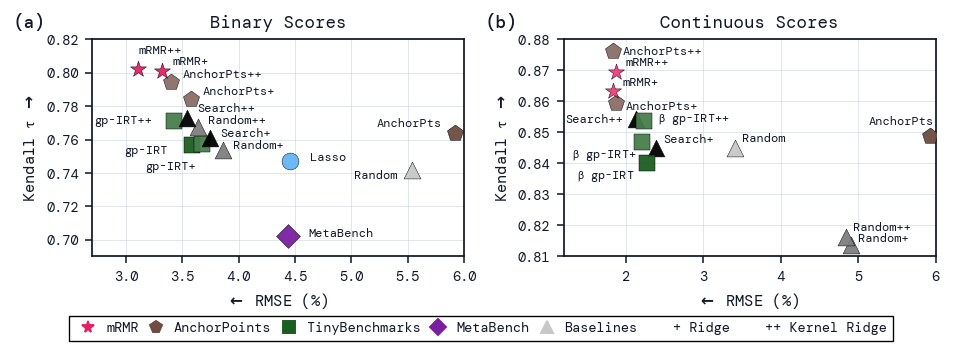

pareto_rmse_tau_binary_vs_cont_plus_passk_with_lasso.pdf


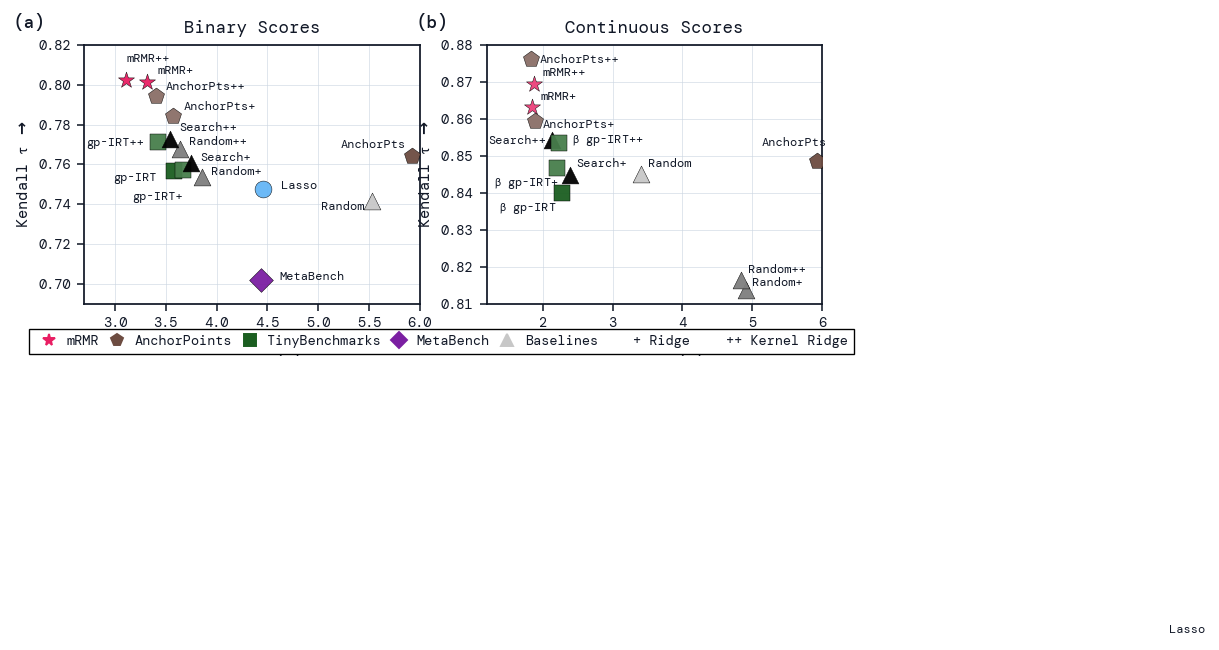

In [3]:
outputs, figures = run_notebook_01(
    binary_setting=BINARY_SETTING,
    continuous_setting=CONTINUOUS_SETTING,
    passk_setting=PASSK_SETTING,
    binary_datasets=BINARY_DATASETS,
    continuous_datasets=CONTINUOUS_DATASETS,
    passk_benchmarks=PASSK_BENCHMARKS,
    methods_binary=METHODS_BINARY,
    methods_continuous=METHODS_CONTINUOUS,
    passk_mrmr_mi_k=PASSK_MRMR_MI_K,
    save_outputs=True,
    show_saved_plots=False,
    return_figures=True,
    close_figures=False,
)

# print(outputs)
import matplotlib.pyplot as plt
for key, fig in figures.items():
    print(key)
    display(fig)
    plt.close(fig)

/tmp/ipykernel_63024/591580559.py:113: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/01_pareto_rmse_tau/pareto_rmse_tau_binary_vs_passk_k1_only_5pct_m15.pdf


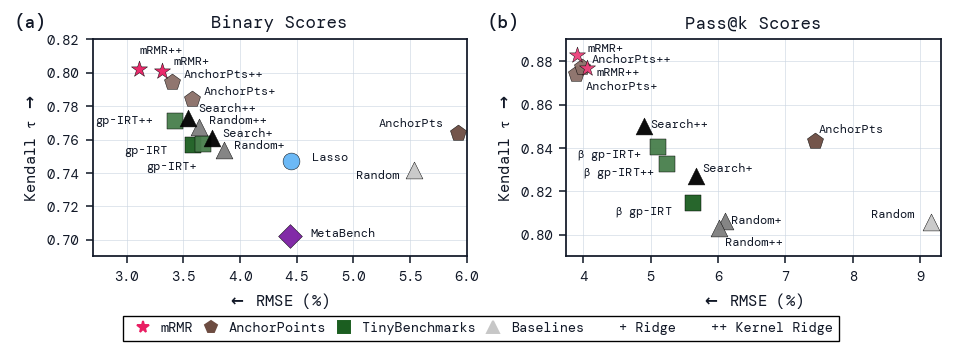

In [26]:
# Extra version: keep left subplot the same, but make the right subplot pass@k only (source k=1).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

bs = _nb_utils.get_setting_flexible(*BINARY_SETTING)
ps = _nb_utils.get_setting_flexible(*PASSK_SETTING)

b_summary = _nb_utils.summarize_setting_standard(bs, datasets=BINARY_DATASETS)
p_summary = _nb_utils.summarize_setting_passk(ps, benchmarks=PASSK_BENCHMARKS, source_mode="k1")

methods_binary_sel = _nb_utils._select_existing_methods(METHODS_BINARY, set(b_summary["method"]))
methods_cont_sel_all = _nb_utils._select_existing_methods(METHODS_CONTINUOUS, set(p_summary["method"]))
methods_cont_sel = [m for m in methods_cont_sel_all if _nb_utils._resolve_method_alias(m) != "lasso"]

b_plot = b_summary[b_summary["method"].isin(methods_binary_sel)].copy()
p_plot = p_summary.set_index("method")

comb_rows = []
p_available = set(p_plot.index.astype(str))
for method in methods_cont_sel:
    passk_method = method
    parsed = _nb_utils.parse_mrmr_method(method)
    if (
        PASSK_MRMR_MI_K is not None
        and parsed is not None
        and parsed["objective"] == "PMIQ"
        and parsed["target"] == "y"
        and parsed["predictor"] == "ridge"
    ):
        passk_primary = _nb_utils.mrmr_method_name(
            degree=parsed["degree"],
            mi_k=int(PASSK_MRMR_MI_K),
            objective="PMIQ",
            target="y",
        )
        passk_method = _nb_utils.resolve_method_candidates([passk_primary, method], p_available) or method

    rmse_val = p_plot["rmse"].get(passk_method, np.nan)
    tau_val = p_plot["tau"].get(passk_method, np.nan)
    if pd.isna(rmse_val) or pd.isna(tau_val):
        continue
    comb_rows.append({"method": method, "rmse": float(rmse_val), "tau": float(tau_val)})

passk_only_plot = pd.DataFrame(comb_rows)

fig, axes = plt.subplots(1, 2, figsize=(_nb_utils.FIG_WIDTH_IN, _nb_utils.FIG_HEIGHT_ONE_ROW_IN), constrained_layout=True)

nudge_left = {
    "random_sampling": (-0.51, -0.005),
    "random_sampling_and_learn": (0.09, 0.001),
    "krandom_sampling_and_learn": (0.09, 0.002),
    "random_search_and_learn": (0.09, 0.001),
    "krandom_search_and_learn": (0.09, 0.004),
    "anchor_points_weighted": (-0.70, 0.004),
    "anchor_points_weighted+": (0.1, 0.003),
    "kanchor_points_weighted+": (0.1, 0.003),
    "gpirt1": (-0.60, -0.005),
    "gpirt1+": (-0.50, -0.015),
    "kgpirt1+": (-0.70, -0.002),
    "mrmr5_MIQ_y": (0.1, 0.004),
    "kmrmr5_MIQ_y": (0.0, 0.009),
}

nudge_right = {
    "random_sampling": (-0.9, 0.002),
    "random_sampling_and_learn": (0.09, -0.001),
    "krandom_sampling_and_learn": (0.09, -0.008),
    "random_search_and_learn": (0.09, 0.002),
    "krandom_search_and_learn": (0.09, -0.001),
    "anchor_points_weighted": (0.05, 0.004),
    "anchor_points_weighted+": (0.15, -0.007),
    "kanchor_points_weighted+": (0.15, 0.002),
    "B_gpirt5": (-1.15, -0.005),
    "B_gpirt5+": (-1.2, -0.005),
    "kB_gpirt5+": (-1.25, -0.005),
    "mrmr_PMIQ_y": (0.15, 0.002),
    "kmrmr_PMIQ_y": (0.15, -0.003),
}

_nb_utils._plot_scatter_with_labels(axes[0], b_plot, "rmse", "tau", nudge_map=nudge_left)
_nb_utils._apply_xy_labels(axes[0], r"$\bf{\leftarrow}$ RMSE (%) ", r"Kendall $\tau$ $\bf{\rightarrow}$")
axes[0].set_title("Binary Scores")

_nb_utils._plot_scatter_with_labels(axes[1], passk_only_plot, "rmse", "tau", nudge_map=nudge_right)
_nb_utils._apply_xy_labels(axes[1], r"$\bf{\leftarrow}$ RMSE (%) ", r"Kendall $\tau$ $\bf{\rightarrow}$")
axes[1].set_title("Pass@k Scores")

axes[0].text(-0.21, 1.12, "(a)", transform=axes[0].transAxes, fontsize=9, fontweight="bold", va="top", ha="left")
axes[1].text(-0.21, 1.12, "(b)", transform=axes[1].transAxes, fontsize=9, fontweight="bold", va="top", ha="left")

legend_methods = list(dict.fromkeys([x for x in methods_binary_sel + methods_cont_sel if x not in ["metabench"]]))
handles = _nb_utils.scatter_legend_handles(legend_methods)
legend = fig.legend(
    handles=handles,
    loc="lower center",
    ncol=max(3, len(handles)),
    frameon=True,
    fancybox=False,
    columnspacing=0.3,
    handletextpad=0.3,
    labelspacing=0.35,
    borderpad=0.45,
    bbox_to_anchor=(0.5, -0.06),
)

axes[0].set_xlim(2.7, 6.0)
axes[0].set_ylim(0.69, 0.82)
axes[1].set_xlim(3.75, 9.3)
axes[1].set_ylim(0.79, 0.89)

_nb_utils._style_legend_box(legend)
fig.tight_layout()

output_dir = _nb_utils._ensure_plot_subdir("01_pareto_rmse_tau")
out = _nb_utils.save_figure(fig, output_dir, "pareto_rmse_tau_binary_vs_passk_k1_only_5pct_m15.pdf")
print(out)

display(fig)
plt.close(fig)
